# Poverty and Resource Distribution Across U.S. States

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 The issue I am addressing is poverty within the United States, with a focus on understanding how it varies across different states. Poverty is a widespread issue, but its distribution and severity differ depending on geographic and economic factors.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 
How does poverty vary by state over time, and is assistance distributed proportionally to areas with the highest need?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 I expect to find that certain states consistently have higher poverty rates than others, and that assistance may not always align with areas of greatest need.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 I- U.S. Census Bureau (poverty rates)
- SNAP dataset (assistance data)
- Bureau of Labor Statistics (optional: unemployment)

## Exploratory Data Analysis (EDA)

At this stage, I explored the datasets to better understand patterns, distributions, and relationships between variables such as poverty rates and SNAP assistance.

### Initial Insights:
- Poverty rates vary significantly across states and over time.
- Some states consistently show higher poverty levels than others.
- SNAP assistance appears to increase in areas with higher poverty, suggesting a relationship between need and support.

### Distributions:
- Poverty rates show a range of values with some states consistently above average.
- SNAP data shows variation in assistance levels across different regions.

### Correlations:
- There appears to be a positive relationship between poverty rates and SNAP assistance.
- Higher poverty areas tend to have higher SNAP participation.

### Data Issues Identified:
- Missing values were found in some rows.
- Some datasets contained inconsistent column names.
- Data types needed to be adjusted for numerical analysis.

### Outliers:
- Some states show unusually high or low poverty rates.
- These outliers are important for analysis and were not removed.

### Missing Values:
- Missing values were identified and handled by removing incomplete rows where necessary.

### Duplicate Values:
- Duplicate rows were checked and removed to ensure data accuracy.

### Data Type Issues:
- Some columns needed to be converted to numeric types for analysis.

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

Raw shape: (115, 9)
                                                    0          1  \
0   Official and Supplemental Poverty Measure (SPM...        NaN   
1                                                 NaN  CPS ASEC1   
2                                                 NaN  Official4   
3                                                 NaN    Percent   
4                                                2024        NaN   
5                                        ..All People       10.6   
6                                    ....Under Age 18       14.3   
7                                    ....Age 18 to 64        9.6   
8                                 ....Age 65 and over        9.9   
9                                                2023        NaN   
10                                       ..All People       11.1   
11                                   ....Under Age 18       15.3   
12                                   ....Age 18 to 64         10   
13                          

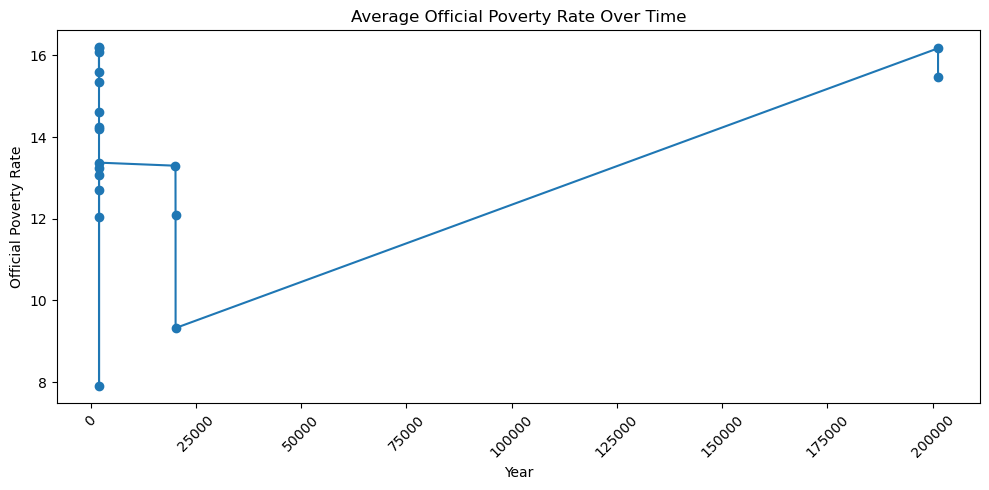

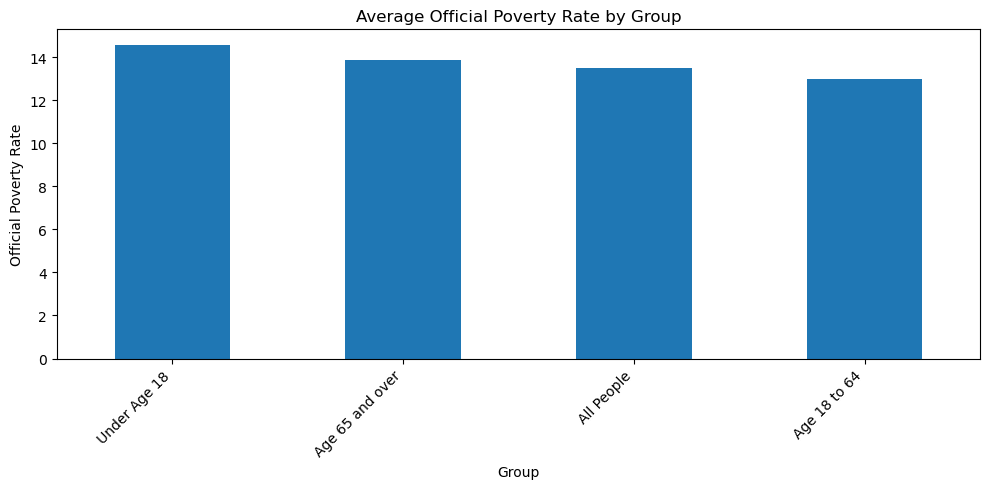

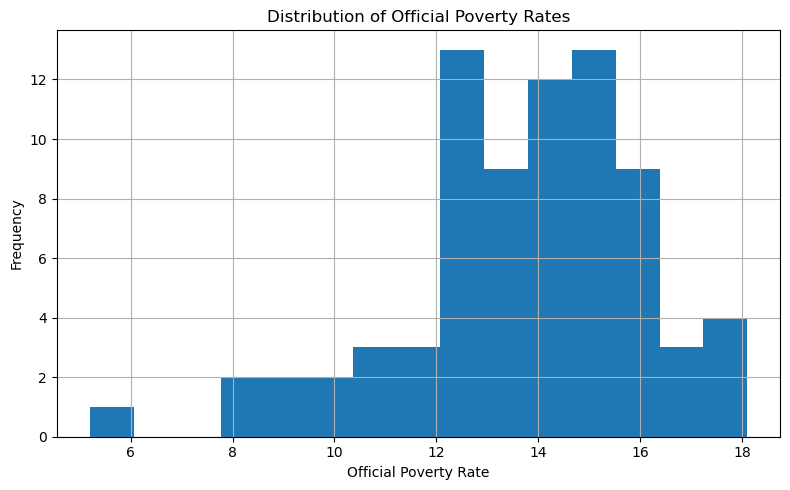

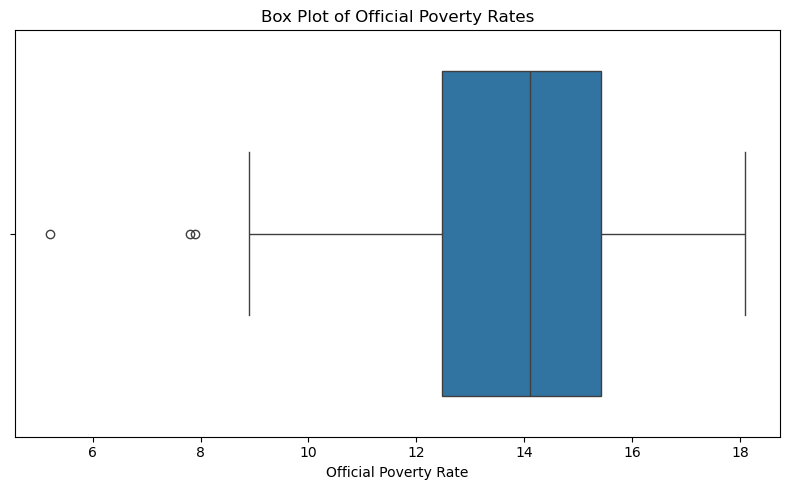


Correlation matrix:
               CPS  Official       SPM
CPS       1.000000   0.49041  0.207406
Official  0.490410   1.00000  0.423720
SPM       0.207406   0.42372  1.000000


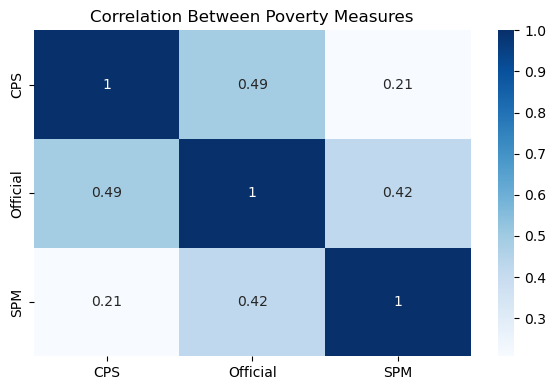

In [6]:
#- Clean and prepare datasets
# - Analyze trends over time
# - Compare poverty and assistance
# - Use visualizations to identify pattern
# Start your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. Load the raw poverty file
# ----------------------------
file_path = "/Users/bennykj04/Downloads/annual_poverty_rates_by_survey.xlsx"

# Read without assuming headers so we can clean it ourselves
raw_poverty = pd.read_excel(file_path, header=None)

print("Raw shape:", raw_poverty.shape)
print(raw_poverty.head(15))

# ----------------------------
# 2. Clean the raw structure
# ----------------------------
# Keep only the first 5 columns since those are the useful ones for this assignment
poverty = raw_poverty.iloc[:, :5].copy()
poverty.columns = ["col0", "col1", "col2", "col3", "col4"]

# Remove fully empty rows
poverty = poverty.dropna(how="all")

# Convert first column to string for easier handling
poverty["col0"] = poverty["col0"].astype(str).str.strip()

# Detect rows where the first column is a year
poverty["Year"] = pd.to_numeric(poverty["col0"], errors="coerce")

# Forward fill the year down to the actual group rows
poverty["Year"] = poverty["Year"].ffill()

# Keep only rows that are actual group rows, not the year-only rows
# Group rows usually start with ".."
poverty = poverty[poverty["col0"].str.startswith("..", na=False)].copy()

# Clean group names
poverty["Group"] = poverty["col0"].str.replace("..", "", regex=False).str.strip()

# Assign the likely data columns
# Based on the structure you showed:
# col1 = CPS ASEC
# col3 = Official
# col4 = SPM
poverty["CPS"] = pd.to_numeric(poverty["col1"], errors="coerce")
poverty["Official"] = pd.to_numeric(poverty["col3"], errors="coerce")
poverty["SPM"] = pd.to_numeric(poverty["col4"], errors="coerce")

# Keep only the cleaned columns we need
poverty = poverty[["Year", "Group", "CPS", "Official", "SPM"]]

# Drop rows that do not have actual poverty values
poverty = poverty.dropna(subset=["Official"])

# Convert Year to integer
poverty["Year"] = poverty["Year"].astype(int)

# Remove duplicates
poverty = poverty.drop_duplicates()

# ----------------------------
# 3. EDA
# ----------------------------
print("\nCleaned poverty data:")
print(poverty.head())

print("\nData types:")
print(poverty.dtypes)

print("\nShape after cleaning:", poverty.shape)

print("\nMissing values:")
print(poverty.isnull().sum())

print("\nDuplicate rows:", poverty.duplicated().sum())

print("\nDescriptive statistics:")
print(poverty.describe())

print("\nUnique groups:")
print(poverty["Group"].unique())

# ----------------------------
# 4. Optional: remove obvious outliers check
# ----------------------------
# For this project, we will keep outliers because they may represent meaningful poverty differences.
q1 = poverty["Official"].quantile(0.25)
q3 = poverty["Official"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = poverty[(poverty["Official"] < lower_bound) | (poverty["Official"] > upper_bound)]
print("\nPotential outliers based on Official poverty rate:")
print(outliers[["Year", "Group", "Official"]])

# ----------------------------
# 5. Visualization 1: Line chart
# Poverty rate over time
# ----------------------------
official_by_year = poverty.groupby("Year")["Official"].mean()

plt.figure(figsize=(10, 5))
plt.plot(official_by_year.index, official_by_year.values, marker="o")
plt.title("Average Official Poverty Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Official Poverty Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------
# 6. Visualization 2: Bar chart
# Poverty rate by group
# ----------------------------
group_avg = poverty.groupby("Group")["Official"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
group_avg.plot(kind="bar")
plt.title("Average Official Poverty Rate by Group")
plt.xlabel("Group")
plt.ylabel("Official Poverty Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------
# 7. Visualization 3: Histogram
# Distribution of Official poverty rate
# ----------------------------
plt.figure(figsize=(8, 5))
poverty["Official"].hist(bins=15)
plt.title("Distribution of Official Poverty Rates")
plt.xlabel("Official Poverty Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ----------------------------
# 8. Visualization 4: Box plot
# Outliers and spread
# ----------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x=poverty["Official"])
plt.title("Box Plot of Official Poverty Rates")
plt.xlabel("Official Poverty Rate")
plt.tight_layout()
plt.show()

# ----------------------------
# 9. Correlation analysis
# ----------------------------
correlation = poverty[["CPS", "Official", "SPM"]].corr()
print("\nCorrelation matrix:")
print(correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap="Blues")
plt.title("Correlation Between Poverty Measures")
plt.tight_layout()
plt.show()

### Visualization 1: Line Chart
This chart shows the average official poverty rate over time. It helps identify whether poverty has increased or decreased across the years in the dataset.

### Visualization 2: Bar Chart
This bar chart compares the average official poverty rate across groups. It makes it easy to see which groups have the highest and lowest poverty rates.

### Visualization 3: Histogram
This histogram shows the distribution of official poverty rates. It helps show how common certain poverty values are and whether the data is concentrated in one range or spread out.

### Visualization 4: Box Plot
This box plot highlights the spread of official poverty rates and identifies possible outliers. It is useful for understanding variation in the data.

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [7]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 9240 bytes to source.py
